# Anàlisi interna dels classificadors CMS

**TCGA-COAD — Classificació de subtipus moleculars de càncer colorectal**

| Camp | Valor |
|------|-------|
| Dataset | 296 mostres entrenament × 74 test × 15.625 gens |
| Models | Logistic Regression, Random Forest, SVM (kernel lineal) |
| Etiquetes | CMS1, CMS2, CMS3, CMS4 (Guinney et al., 2015) |
| Seed | 42 |

---

Aquest notebook examina l'estructura interna dels tres classificadors entrenats:
quins gens han rebut més pes, com prenen les decisions i per quin motiu
s'espera que cadascun es comporti d'una manera determinada amb el conjunt de test.

Les prediccions de rendiment formulades al final de cada secció es validen
al notebook `results_exploration.ipynb`.

**Estructura:**

0. Configuració
1. Notació i terminologia
2. Disseny experimental dels models
3. Regressió Logística — formulació, coeficients i hipòtesi
4. Random Forest — formulació, importàncies i hipòtesi
5. SVM — formulació, vectors de suport i hipòtesi
6. Prediccions sobre el rendiment en el test set

---

## 0. Configuració

La cel·la següent importa les llibreries necessàries i estableix els camins
als directoris de dades, models i figures. Si l'execució és correcta, s'imprimeix
un resum de confirmació.

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import export_text
from IPython.display import display

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.evaluation import (
    CMS_ORDER, CMS_PALETTE, MODEL_DISPLAY_NAMES,
    load_models,
)
from src.models import load_processed_data

PROCESSED = ROOT / 'data' / 'processed'
MODELS    = ROOT / 'data' / 'models'
FIGURES   = ROOT / 'figures'

plt.rcParams.update({
    'figure.dpi':        120,
    'font.size':          11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

print('Setup completat.')
print(f'  Root: {ROOT}')
print(f'  Models dir: {MODELS}')

Setup completat.
  Root: /home/mrivero/tcga-coad-cms-ml-pipeline
  Models dir: /home/mrivero/tcga-coad-cms-ml-pipeline/data/models


La cel·la següent carrega les dades processades i els models entrenats des del disc.
S'espera veure les dimensions del dataset (296 × 15.625 per al train, 74 × 15.625 per al test)
i la distribució de classes a cadascun dels dos conjunts.

In [2]:
X_train, X_test, y_train, y_test = load_processed_data(PROCESSED)
models = load_models(MODELS)

print('Dades carregades:')
print(f'  X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'  y_train: {y_train.value_counts().sort_index().to_dict()}')
print(f'  y_test:  {y_test.value_counts().sort_index().to_dict()}')
print()
print(f'Models carregats: {list(models.keys())}')

Dades carregades:
  X_train: (296, 15625)  |  X_test: (74, 15625)
  y_train: {'CMS1': 57, 'CMS2': 116, 'CMS3': 43, 'CMS4': 80}
  y_test:  {'CMS1': 14, 'CMS2': 29, 'CMS3': 11, 'CMS4': 20}

Models carregats: ['logistic_regression', 'random_forest', 'svm']


La cel·la següent carrega el fitxer `gene_names.csv`, que conté la correspondència
entre l'identificador GENCODE de cada gen (`ENSG00000...`) i el seu nom biològic
convencional (p. ex. `TSPAN6`). Aquesta correspondència s'usa a les seccions 3 i 4
per mostrar noms llegibles als gràfics de coeficients i importàncies.

In [3]:
gene_names_df = pd.read_csv(PROCESSED / 'gene_names.csv')

gene_name_map: dict[str, str] = dict(
    zip(gene_names_df['gene_id'], gene_names_df['gene_name'])
)

def get_gene_name(gene_id: str) -> str:
    return gene_name_map.get(gene_id, gene_id)

print(f'gene_names.csv carregat: {len(gene_name_map)} gens')
print(f'Exemples: {dict(list(gene_name_map.items())[:3])}')

gene_names.csv carregat: 15625 gens
Exemples: {'ENSG00000000003.15': 'TSPAN6', 'ENSG00000000005.6': 'TNMD', 'ENSG00000000419.13': 'DPM1'}


---

## 1. Notació i terminologia

Aquesta secció recull les definicions dels conceptes biològics i estadístics
emprats al llarg del notebook. L'objectiu és facilitar-ne la lectura per a
lectors amb formació en informàtica però sense especialització en bioinformàtica
o aprenentatge automàtic. Per a una referència completa, consulteu el
[glossari del projecte](../docs/glossary.md).

### Conceptes biològics

**RNA-seq** és una tecnologia experimental que mesura el nivell d'activitat
(*expressió*) de cada gen en una mostra de teixit tumoral. El resultat és una
matriu numèrica: cada columna és un pacient, cada fila és un gen, i cada valor
és un comptatge proporcional a la quantitat de missatger que aquell gen produïa
en el moment de la biòpsia.

**Gen / Feature:** en aprenentatge automàtic, cada gen és una variable d'entrada
(*feature*) del model. En aquest projecte, cada pacient es representa com un
vector de 15.625 valors numèrics, un per gen.

**Subtipus CMS** — el càncer colorectal es classifica en quatre subtipus moleculars
definits per Guinney et al. (2015):

| Subtipus | Nom | Característica principal | Mostres train | Mostres test |
|:--------:|-----|-------------------------|:-------------:|:------------:|
| CMS1 | MSI Immune | Alta activitat immune | 57 | 14 |
| CMS2 | Canonical | Activació WNT/MYC | 116 | 29 |
| CMS3 | Metabolic | Desregulació metabòlica (perfil mixt) | 43 | 11 |
| CMS4 | Mesenchymal | Activació TGF-β | 80 | 20 |

CMS3 és el subtipus menys representat (43/296 = 15%) i el que presenta un
perfil d'expressió gènica menys diferenciat respecte als altres subtipus.
Això el converteix en el cas d'ús més exigent per a qualsevol classificador.

### Mètriques d'avaluació

#### Accuracy

L'**accuracy** és la proporció de mostres classificades correctament sobre el total:

$$\text{Accuracy} = \frac{\text{prediccions correctes}}{\text{total mostres}}$$

És la mètrica més intuïtiva, però té una limitació important quan les classes
estant desbalancejades. Imagineu un model que **sempre predís CMS2** per a
tota mostra del test:

- Accuracy = 29/74 ≈ 39% (perquè 29 de les 74 mostres realment son CMS2)
- Però Recall(CMS1) = 0/14 = **0%**, Recall(CMS3) = 0/11 = **0%**, Recall(CMS4) = 0/20 = **0%**

L'accuracy del 39% podria semblar acceptable, però amaga que tres quartes parts
de les mostres — tots els CMS1, CMS3 i CMS4 — serien ignorades completament.
Per aquest motiu es complementa l'accuracy amb precision i recall.

#### TP, FP, FN i TN

Abans de definir precision i recall, calen quatre comptadors per a cada classe.
Prenent **CMS3** com a exemple i els resultats reals del model sobre les 11 mostres
CMS3 del test set:

| Símbol | Nom | Definició per a CMS3 | Valor real (LR) |
|:------:|-----|----------------------|:---------------:|
| **TP** | True Positive | Pacients CMS3 classificats **correctament** com CMS3 | 10 |
| **FN** | False Negative | Pacients CMS3 classificats **erròniament** com un altre subtipus | 1 |
| **FP** | False Positive | Pacients d'un **altre** subtipus classificats erròniament com CMS3 | 0 |
| **TN** | True Negative | Tots els no-CMS3 classificats correctament com no-CMS3 | 63 |

El model ha identificat 10 de 11 pacients CMS3. L'únic error és un pacient
CMS3 que ha estat classificat com CMS2 (FN=1). Cap pacient d'un altre subtipus
ha estat etiquetat com CMS3 (FP=0).

#### Precision i Recall

Amb els comptadors anteriors es defineixen:

$$\text{Precision}_{\text{CMS3}} = \frac{TP}{TP + FP} = \frac{10}{10 + 0} = 1.0$$

$$\text{Recall}_{\text{CMS3}} = \frac{TP}{TP + FN} = \frac{10}{10 + 1} = 0.\overline{909}$$

**Precision = 1.0** significa que *totes* les mostres que el model ha etiquetat
com CMS3 eren realment CMS3 — no hi ha falsos positius.

**Recall = 0.909** significa que el model ha detectat 10 de les 11 mostres
CMS3 reals — n'ha perdut 1.

En diagnòstic clínic, el Recall és sovint la mètrica més crítica:
un FN (pacient malalt no detectat) pot tenir conseqüències greus.
Un FP (pacient sa diagnosticat erròniament) implica proves addicionals, però
és menys perillós.

#### F1-score

El **F1-score** és la **mitjana harmònica** de precision i recall:

$$F1 = 2 \cdot \frac{P \cdot R}{P + R}$$

La mitjana harmònica penalitza fortament els valors desequilibrats.
Si P=1.0 i R=0.0, el F1=0 — no serveix de res tenir precisió perfecta
si no es detecta cap cas positiu.

La figura següent il·lustra el comportament del F1 en quatre escenaris
típics, per mostrar com la penalització actua en funció de l'equilibri entre P i R.

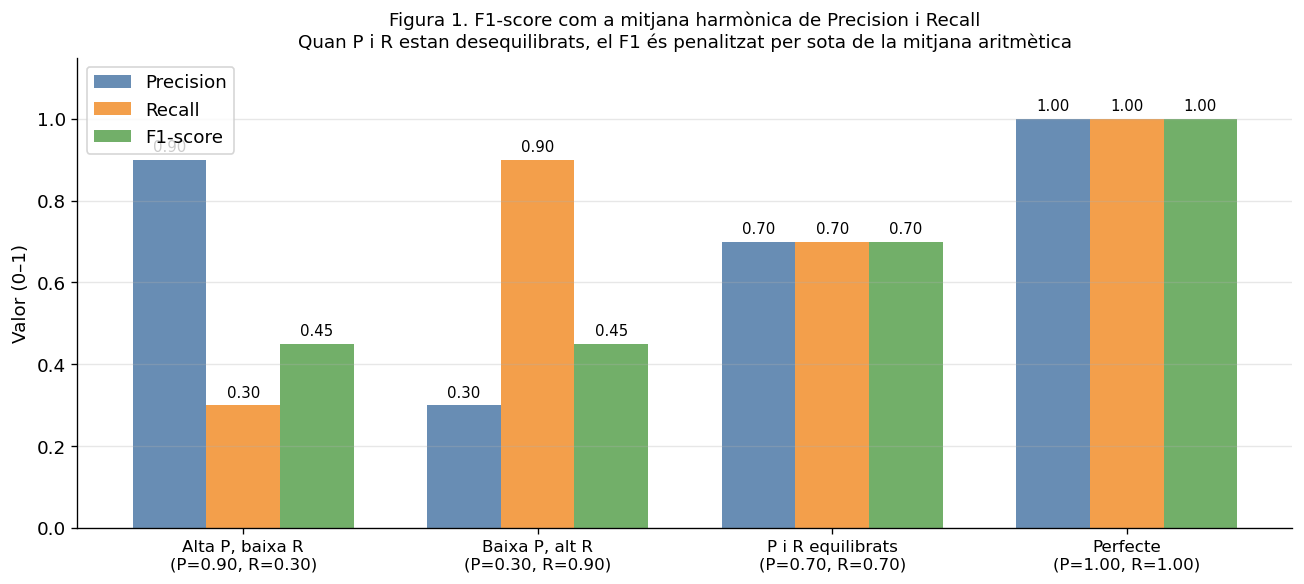

Observació clau: els escenaris 1 i 2 tenen P i R intercanviats però
obtenen exactament el mateix F1 (la fórmula és simètrica).
Quan P=R, el F1 és igual a P i R. Quan P≠R, F1 < (P+R)/2.


In [4]:
# Comparació de 4 escenaris per il·lustrar el comportament del F1
labels_raw = [
    ('Alta P, baixa R\n(P=0.90, R=0.30)', 0.90, 0.30),
    ('Baixa P, alt R\n(P=0.30, R=0.90)',  0.30, 0.90),
    ('P i R equilibrats\n(P=0.70, R=0.70)', 0.70, 0.70),
    ('Perfecte\n(P=1.00, R=1.00)',          1.00, 1.00),
]

labels = [s[0] for s in labels_raw]
P_vals  = [s[1] for s in labels_raw]
R_vals  = [s[2] for s in labels_raw]
F1_vals = [2*p*r/(p+r) if (p+r) > 0 else 0.0 for p, r in zip(P_vals, R_vals)]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
bars_P  = ax.bar(x - width, P_vals,  width, label='Precision', color='#4e79a7', alpha=0.85)
bars_R  = ax.bar(x,          R_vals,  width, label='Recall',    color='#f28e2b', alpha=0.85)
bars_F1 = ax.bar(x + width, F1_vals, width, label='F1-score',  color='#59a14f', alpha=0.85)

for bars in (bars_P, bars_R, bars_F1):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Valor (0–1)')
ax.set_title(
    'Figura 1. F1-score com a mitjana harmònica de Precision i Recall\n'
    'Quan P i R estan desequilibrats, el F1 és penalitzat per sota de la mitjana aritmètica',
    fontsize=11
)
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Observació clau: els escenaris 1 i 2 tenen P i R intercanviats però')
print('obtenen exactament el mateix F1 (la fórmula és simètrica).')
print('Quan P=R, el F1 és igual a P i R. Quan P≠R, F1 < (P+R)/2.')

#### F1 macro

Amb quatre classes (CMS1–CMS4), cada classe té el seu propi F1-score.
El **F1 macro** és el promig simple dels quatre F1-scores:

$$F1_{\text{macro}} = \frac{F1_{\text{CMS1}} + F1_{\text{CMS2}} + F1_{\text{CMS3}} + F1_{\text{CMS4}}}{4}$$

Aquest promig **no pondera** per la freqüència de cada classe: CMS3 (11 mostres)
compta igual que CMS2 (29 mostres). Aquesta propietat fa que el F1 macro sigui
la mètrica de referència d'aquest benchmark, ja que penalitza els errors en
classes minoritàries igual que els errors en classes majoritàries.

---

## 2. Disseny experimental dels models

Tots tres classificadors comparteixen un paràmetre comú durant l'entrenament:
`class_weight='balanced'`. No és una mètrica d'avaluació, sinó un mecanisme
de compensació del desbalanceig de classes que s'aplica **durant l'entrenament**.

### Per qué és necessari?

Sense compensació, el model optimitza l'error global i tendeix a afavorir
les classes freqüents. Com que CMS2 representa el 39% del train (116/296),
un model no compensat podria obtenir un accuracy acceptable malgrat ignorar
CMS3 (15%). `class_weight='balanced'` corregeix aquest biaix assignant un pes
major a les mostres de les classes menys representades.

### Com funciona?

Cada mostra d'entrenament rep un pes inversament proporcional a la freqüència
de la seva classe:

$$w_k = \frac{N}{K \cdot N_k}$$

on $N=296$ (total train), $K=4$ (classes) i $N_k$ és el nombre de mostres
de la classe $k$.

| Subtipus | Nom biològic | $N_k$ (train) | Pes $w_k$ | Vs. CMS2 | Efecte a l'entrenament |
|:---:|:---:|:---:|:---:|:---:|---|
| CMS1 | MSI Immune | 57 | ≈ 1.30 | 2.0× | Doble importància que CMS2 |
| CMS2 | Canonical | 116 | ≈ 0.64 | 1.0× (referència) | Pes de referència (classe majoritària) |
| CMS3 | Metabolic | 43 | ≈ 1.72 | 2.7× | 2.7 vegades més pes que CMS2 |
| CMS4 | Mesenchymal | 80 | ≈ 0.93 | 1.4× | Lleugerament superior a CMS2 |

Concretament: cada error sobre una mostra CMS3 penalitza el model 2.7 vegades
més que un error sobre una mostra CMS2. Sense aquest paràmetre, el F1(CMS3)
seria sensiblement inferior.

---

## 3. Regressió Logística

### Principi de funcionament

La Regressió Logística aprèn un **pes** $w_{kj}$ per a cada combinació de
classe $k$ i gen $j$. Donat un pacient nou, el model calcula una puntuació
per a cada subtipus CMS sumant el producte (valor d'expressió × pes) sobre
els 15.625 gens:

$$z_{ik} = \sum_{j=1}^{15625} w_{kj} \cdot x_{ij} + b_k$$

Per il·lustrar-ho, considerem tres gens hipotètics per a la classe CMS3:

| Gen | Pes $w_{\text{CMS3},j}$ | Interpretació |
|-----|:-----------------------:|---------------|
| Gen A (metabòlic) | +2.5 | Expressió alta → evidència *a favor* de CMS3 |
| Gen B (immune) | −1.8 | Expressió alta → evidència *en contra* de CMS3 |
| Gen C (no rellevant) | ≈ 0 | No contribueix a la predicció CMS3 |

El model fa aquest càlcul per a les 4 classes simultàniament i converteix
les quatre puntuacions en probabilitats amb la funció softmax.

### Formulació matemàtica

**Pas 1 — Puntuació lineal** per a la mostra $i$ i la classe $k$:

$$z_{ik} = \mathbf{w}_k \cdot \mathbf{x}_i + b_k = \sum_{j=1}^{15625} w_{kj} \cdot x_{ij} + b_k$$

On $\mathbf{x}_i \in \mathbb{R}^{15625}$ és el vector d'expressió log₂ del pacient $i$,
$\mathbf{w}_k \in \mathbb{R}^{15625}$ és el vector de pesos de la classe $k$,
i $b_k$ és el biaix (*intercept*).

**Pas 2 — Funció softmax** (conversió a probabilitats sobre les 4 classes):

$$P(\text{CMS}=k \mid \mathbf{x}_i) = \frac{e^{z_{ik}}}{\sum_{m=1}^{4} e^{z_{im}}}$$

La funció softmax garanteix que les probabilitats de les 4 classes sumen 1.
A tall d'exemple amb puntuacions hipotètiques:

| $z_{\text{CMS1}}$ | $z_{\text{CMS2}}$ | $z_{\text{CMS3}}$ | $z_{\text{CMS4}}$ | Softmax (aprox.) | Classe predita |
|:-----------------:|:-----------------:|:-----------------:|:-----------------:|:----------------:|:--------------:|
| 1.2 | **4.8** | 0.3 | 1.1 | 0.05, **0.85**, 0.02, 0.08 | **CMS2** |
| 0.5 | 0.8 | **5.1** | 0.3 | 0.01, 0.02, **0.95**, 0.02 | **CMS3** |

### Aplicació al conjunt TCGA-COAD — coeficients per subtipus

Un dels avantatges de la Regressió Logística és que els pesos apresos son
directament interpretables: un coeficient positiu elevat per a la classe CMS3
indica que l'expressió alta d'aquell gen incrementa la probabilitat predita de
CMS3. Un coeficient negatiu fa el contrari.

La figura següent mostra els **top 10 gens** amb major coeficient positiu per
a cadascun dels quatre subtipus CMS. La comparació dels quatre panells permet
identificar si els models han après signatures específiques per a cada subtipus
o si alguns gens apareixen com a discriminatius en múltiples classes.

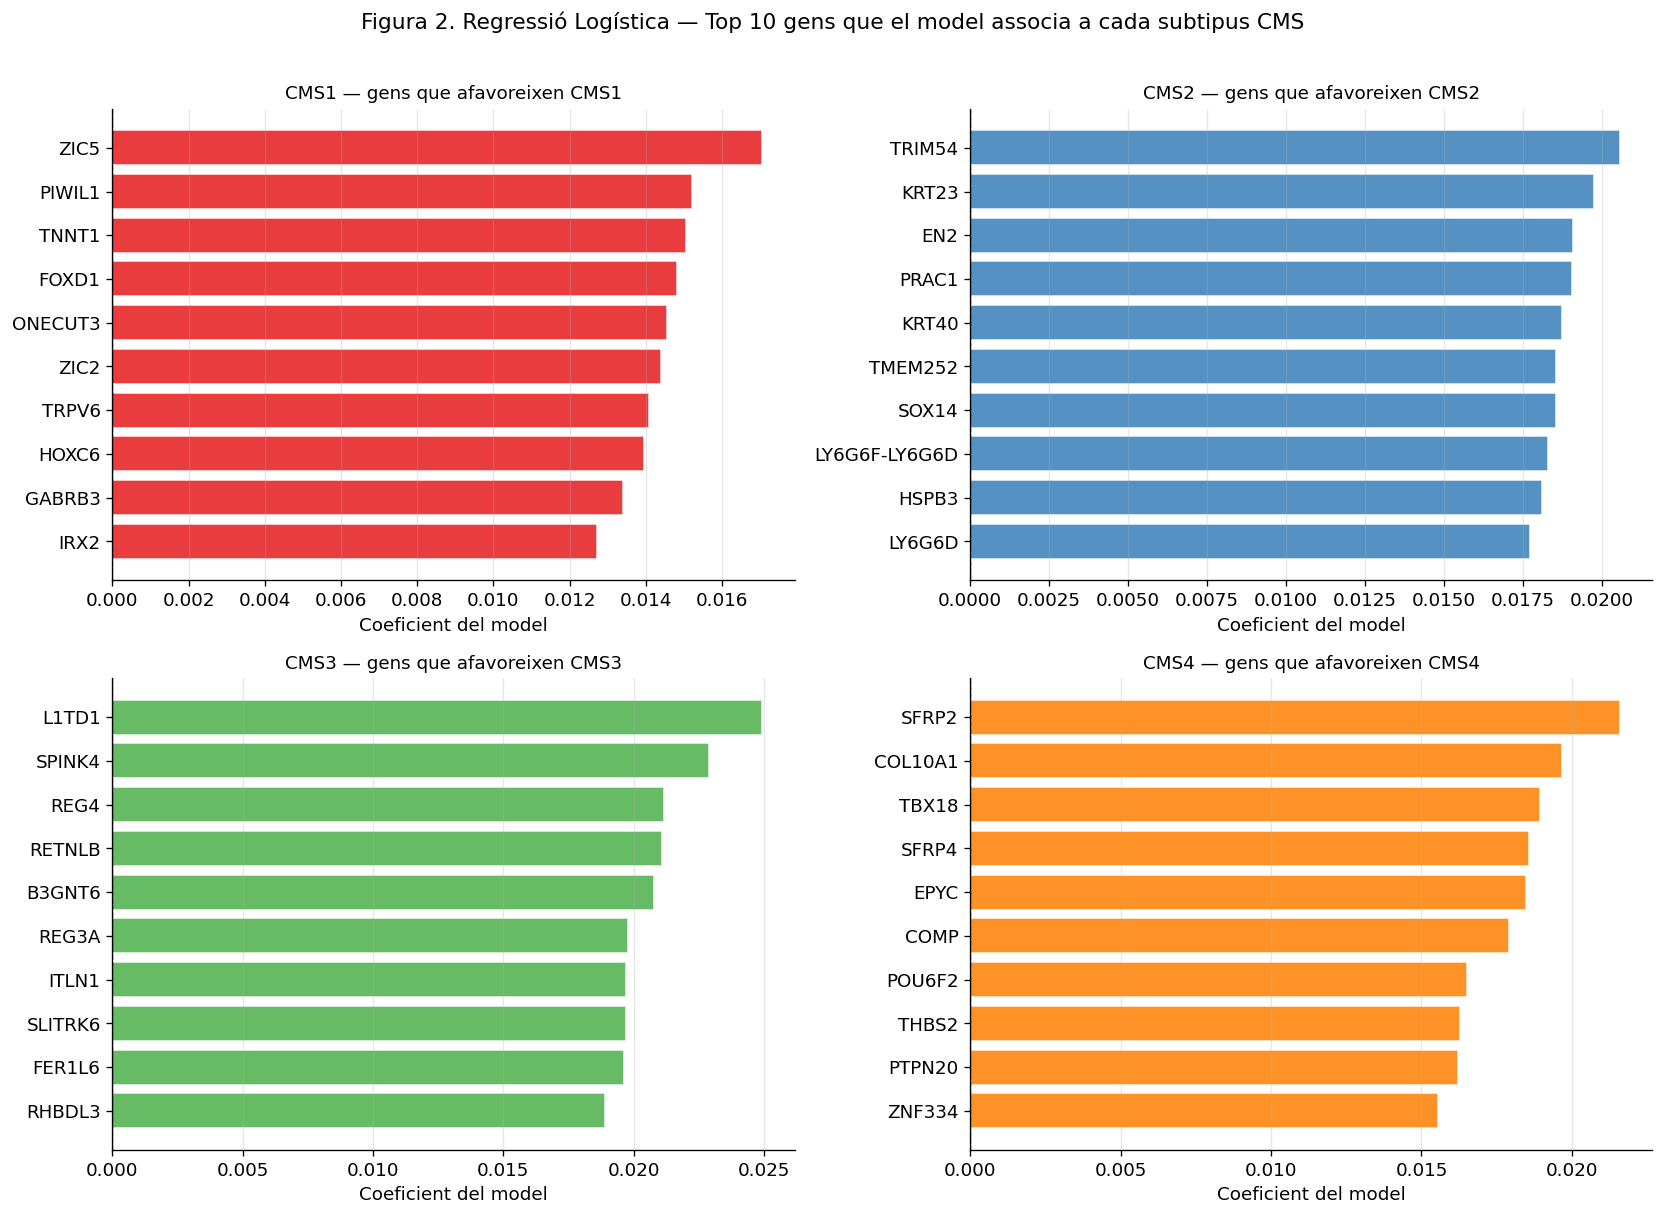

In [5]:
lr_model = models['logistic_regression']

# coef_df guarda els coeficients de CMS3 — es reutilitza a la secció SVM (cel·la posterior)
cms3_idx = list(lr_model.classes_).index('CMS3')
coef_df = pd.DataFrame({
    'gene_id':   X_train.columns,
    'coef_CMS3': lr_model.coef_[cms3_idx],
})
coef_df['gene_name'] = coef_df['gene_id'].map(gene_name_map).fillna(coef_df['gene_id'])

# Gràfic 2x2: top 10 gens pro-CMS per a cadascun dels quatre subtipus
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Figura 2. Regressió Logística — Top 10 gens que el model associa a cada subtipus CMS',
    fontsize=13, y=1.01
)

for ax, cms_class in zip(axes.flatten(), CMS_ORDER):
    cls_idx = list(lr_model.classes_).index(cms_class)
    cls_df  = pd.DataFrame({
        'gene_id': X_train.columns,
        'coef':    lr_model.coef_[cls_idx],
    })
    cls_df['gene_name'] = cls_df['gene_id'].map(gene_name_map).fillna(cls_df['gene_id'])
    top10 = cls_df.nlargest(10, 'coef')

    ax.barh(top10['gene_name'][::-1], top10['coef'][::-1],
            color=CMS_PALETTE[cms_class], alpha=0.85, edgecolor='white')
    ax.set_xlabel('Coeficient del model')
    ax.set_title(f'{cms_class} — gens que afavoreixen {cms_class}', fontsize=11)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretació dels coeficients:**

Els gens amb coeficient positiu més elevat constitueixen la signatura molecular
que el model associa amb cada subtipus. Quan el nivell d'expressió d'un d'aquests
gens és alt en un pacient nou, la probabilitat predita d'aquell subtipus augmenta.

Cal observar si els quatre panells mostren gens **exclusius** per a cada subtipus
o si hi ha **solapament** entre classes. Un solapament elevat indicaria que
la separació entre subtipus no és nítida en l'espai de gens.

Els gens amb coeficients molt positius per a CMS3 s'espera que estiguin relacionats
amb la desregulació metabòlica característica del subtipus CMS3 (Guinney et al., 2015).
Els gens amb coeficients molt positius per a CMS1 s'espera que estiguin relacionats
amb la resposta immune.

### Probabilitats softmax per mostra

A diferència d'un classificador que emet únicament una etiqueta, la Regressió
Logística assigna una **distribució de probabilitats** sobre els quatre subtipus
per a cada pacient. Examinar aquestes probabilitats permet saber si el model
decideix amb alta confiança (una classe domina amb >0.90) o si es troba
indecís entre dues opcions (dues classes amb probabilitats similars).

La taula següent mostra les probabilitats softmax per a les 5 primeres mostres
del test set. La cel·la amb el color més fosc indica la classe predita.

In [6]:
proba = lr_model.predict_proba(X_test.iloc[:5])

proba_df = pd.DataFrame(
    proba,
    columns=lr_model.classes_,
    index=[f'Mostra {i+1}' for i in range(5)]
)
proba_df['Predicció'] = lr_model.predict(X_test.iloc[:5])
proba_df['Real']      = y_test.values[:5]

styled = (
    proba_df.style
    .background_gradient(cmap='Blues', subset=list(lr_model.classes_), vmin=0, vmax=1)
    .format({c: '{:.3f}' for c in lr_model.classes_})
    .set_caption(
        'Taula 2. Probabilitats softmax per a les 5 primeres mostres de test '
        '(Regressió Logística). El color més fosc indica la classe predita.'
    )
)
display(styled)

,CMS1,CMS2,CMS3,CMS4,Predicció,Real
Mostra 1,0.000,0.997,0.000,0.003,CMS2,CMS2
Mostra 2,0.999,0.000,0.000,0.000,CMS1,CMS1
Mostra 3,0.001,0.352,0.000,0.648,CMS4,CMS4
Mostra 4,0.999,0.000,0.000,0.001,CMS1,CMS1
Mostra 5,0.000,0.975,0.025,0.000,CMS2,CMS2


**Interpretació de les probabilitats:**

En la gran majoria de mostres s'espera que una classe domini amb probabilitat
>0.80 i les altres tres sumen <0.20. Aquesta concentració indica que el model
decideix amb alta confiança.

Les mostres on dues classes tenen probabilitats properes (p. ex. 0.55 vs. 0.40)
son les candidates a ser mal classificades — especialment quan la classe real
coincideix amb la segona opció del model.

### Hipòtesi de rendiment

> **H1a — Logistic Regression:** El model hauria d'obtenir un rendiment elevat
> al test set. Utilitza els 15.625 gens alhora per prendre cada decisió, i durant
> l'entrenament penalitza automàticament els pesos massa grans per evitar que el
> model s'aprengui el conjunt de train de memòria. Ambdues propietats fan que sigui
> especialment adequat quan hi ha moltes més variables que mostres — com és el cas:
> 15.625 gens per a 296 pacients.

---

## 4. Random Forest

### Principi de funcionament

El Random Forest és un mètode d'*ensemble*: construeix 500 arbres de decisió
independents i pren la predicció per majoria de vots. Cada arbre s'entrena
de manera diferent gràcies a dues fonts d'aleatorietat:

1. **Bootstrap:** cada arbre rep una còpia del dataset obtinguda per mostratge
   amb reemplaçament (alguns pacients apareixeran 2-3 vegades; d'altres no
   apareixeran). Cada arbre aprèn sobre una visió lleugerament diferent de les dades.

2. **Aleatorietat de features:** en cada nus de divisió, l'arbre només considera
   un subconjunt aleatori de $\sqrt{15625} \approx 125$ gens, no els 15.625 complets.

La combinació d'ambdues tècniques genera 500 arbres *diversificats*: cadascun
comet errors en llocs diferents, i els errors s'atenuen parcialment per la votació
majoritària.

### Formulació matemàtica

**Criteri de divisió — Impuresa de Gini:**

Per a un nus $t$ amb proporció de mostres $p_k$ de la classe $k$:

$$\text{Gini}(t) = 1 - \sum_{k=1}^{4} p_k^2$$

- Gini = 0 → nus **pur** (totes les mostres son de la mateixa classe)
- Gini = 0.75 → nus completament **impur** (25% de cada classe)

En cada nus de decisió, l'arbre cerca el gen i el llindar d'expressió (sobre
un subconjunt de ~125 gens) que maximitzi la reducció de Gini entre el nus
pare i els nusos fills.

**Predicció:** cadascun dels 500 arbres emet una etiqueta per a una mostra nova
(la classe dominant a la fulla on cau la mostra). La classe amb més vots guanya.

**Importància de feature** (*feature importance*) del gen $j$:

$$\text{Importància}(j) = \frac{1}{500} \sum_{t=1}^{500} \Delta\text{Gini}_j^{(t)}$$

Promig de la reducció de Gini produïda per les divisions sobre el gen $j$
als 500 arbres. Mesura quant contribueix cada gen a la classificació global.

### Aplicació al conjunt TCGA-COAD — importàncies de features

**Important:** la importança del Random Forest és una mesura **global** — indica quant
contribueix cada gen a separar *totes* les classes entre elles, sense especificar quin
subtipus afavoreix. Difereix dels coeficients de la Regressió Logística, que son
específics de cada classe (pro-CMS1, pro-CMS2, etc.).

La figura següent mostra els **top 20 gens** per importança promig als 500 arbres.
S'espera que les importàncies estiguin molt distribuïdes: si cap gen domina,
voldrà dir que la signatura molecular dels subtipus CMS requereix la contribució
conjunta de molts gens, no d'uns pocs amb efecte dominant. Al final del codi,
es comprova si el top 5 del RF coincideix amb els gens pro-CMS3 de la LR.

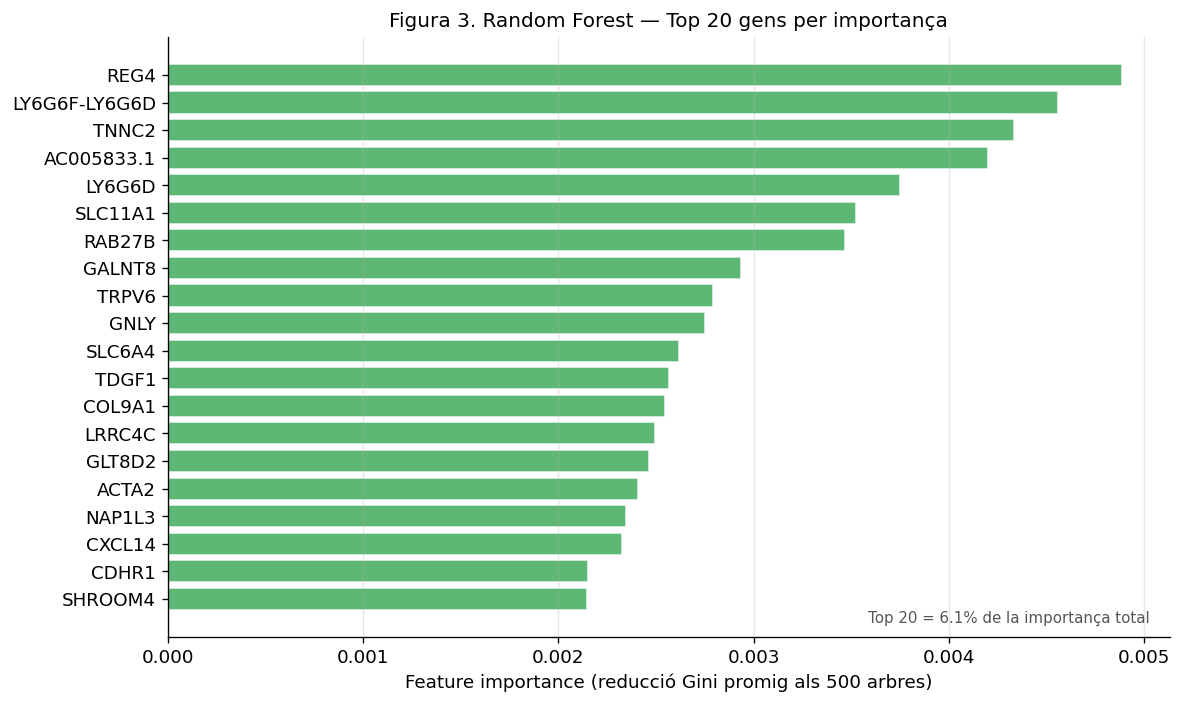

Top 5 gens per importança (Random Forest):
  REG4                  importance=0.004886
  LY6G6F-LY6G6D         importance=0.004559
  TNNC2                 importance=0.004334
  AC005833.1            importance=0.004200
  LY6G6D                importance=0.003751

--- Nota comparativa amb la Logistic Regression ---
Top 5 gens RF (importança global):  ['AC005833.1', 'LY6G6D', 'LY6G6F-LY6G6D', 'REG4', 'TNNC2']
Top 10 gens LR (pro-CMS3):          ['B3GNT6', 'FER1L6', 'ITLN1', 'L1TD1', 'REG3A', 'REG4', 'RETNLB', 'RHBDL3', 'SLITRK6', 'SPINK4']
Gens en comú:                        ['REG4']


In [7]:
rf_model = models['random_forest']

imp_df = pd.DataFrame({
    'gene_id':    X_train.columns,
    'importance': rf_model.feature_importances_,
})
imp_df['gene_name'] = imp_df['gene_id'].map(gene_name_map).fillna(imp_df['gene_id'])

top20 = imp_df.nlargest(20, 'importance')
total_top20 = top20['importance'].sum()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top20['gene_name'][::-1], top20['importance'][::-1],
        color='#41ab5d', alpha=0.85, edgecolor='white')
ax.set_xlabel('Feature importance (reducció Gini promig als 500 arbres)')
ax.set_title('Figura 3. Random Forest — Top 20 gens per importança', fontsize=12)
ax.text(0.98, 0.02,
        f'Top 20 = {total_top20*100:.1f}% de la importança total',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9, color='#555')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('Top 5 gens per importança (Random Forest):')
for _, row in top20.head(5).iterrows():
    print(f"  {row['gene_name']:20s}  importance={row['importance']:.6f}")

# Nota comparativa: solapament amb els gens pro-CMS3 de la LR (coef_df definit a la secció 3)
print()
print('--- Nota comparativa amb la Logistic Regression ---')
top5_rf       = set(top20.head(5)['gene_name'])
top10_lr_cms3 = set(coef_df.nlargest(10, 'coef_CMS3')['gene_name'])
overlap_rf_lr = top5_rf & top10_lr_cms3
print(f'Top 5 gens RF (importança global):  {sorted(top5_rf)}')
print(f'Top 10 gens LR (pro-CMS3):          {sorted(top10_lr_cms3)}')
print(f'Gens en comú:                        {sorted(overlap_rf_lr) if overlap_rf_lr else "(cap)"}')

**Interpretació de les importàncies:**

Si les importàncies estan molt distribuïdes i el top 20 representa només un petit
percentatge del total, això indica que la signatura molecular dels subtipus CMS
és el resultat de petites contribucions de milers de gens, no d'uns pocs dominants.

Aquest tipus de senyal és capturat de manera més eficient per models que consideren
tots els gens **simultàniament** (com la Regressió Logística), que per models que
basen cada decisió en un sol gen a la vegada (com el Random Forest).

### Estructura d'un arbre individual

Per il·lustrar el mecanisme de decisió intern, la cel·la següent mostra l'arbre #0
dels 500 que formen el Random Forest. Per fer-lo llegible, es mostren les primeres
2 profunditats (màxim 7 nodes).

**Camps de cada node (rectangle):**

| Camp | Significat |
|------|------------|
| `GEN <= llindar` | El gen que es comprova i el llindar d'expressió que separa les mostres |
| `samples` | Nombre de mostres del **train set** que arriben a aquest node |
| `value = [n1, n2, n3, n4]` | D'aquelles mostres, quantes pertanyen a CMS1, CMS2, CMS3 i CMS4 respectivament |
| `class` | La classe dominant (la que té el número més alt a `value`) |
| **Color** | Reflecteix la classe dominant — si l'arbre s'aturés aquí, prediries aquesta classe |

**Important:** el valor d'expressió del pacient que s'analitza **no apareix al node** —
cada node aporta el *llindar* (del model) i el pacient aporta el seu *valor* (les seves dades).
La decisió en cada node és:
- Si expressió del pacient ≤ llindar → fill esquerre
- Si expressió del pacient > llindar → fill dret

Per facilitar la comprensió, el codi mostra primer una taula amb els valors d'expressió
de la mostra en els gens del camí, després el diagrama de l'arbre, i finalment
el camí recorregut pas a pas.

Mostra analitzada: Mostra 1 del test set  (classe real: CMS2)

Valors d'expressió de la mostra en els gens que apareixeran al camí de l'arbre:


,Gen del node,Expressió de la mostra,Llindar de l'arbre,Decisió
Nivell,,,,
Nivell 1,TAGLN,13.51,12.29,Exp > Llindar → fill dret
Nivell 2,SGPP2,11.23,12.13,Exp <= Llindar → fill esquerre
Nivell 3,EIF3G,12.81,13.13,Exp <= Llindar → fill esquerre
Nivell 4,SNRPB,12.58,14.00,Exp <= Llindar → fill esquerre
Nivell 5,ZNF599,7.94,8.25,Exp <= Llindar → fill esquerre


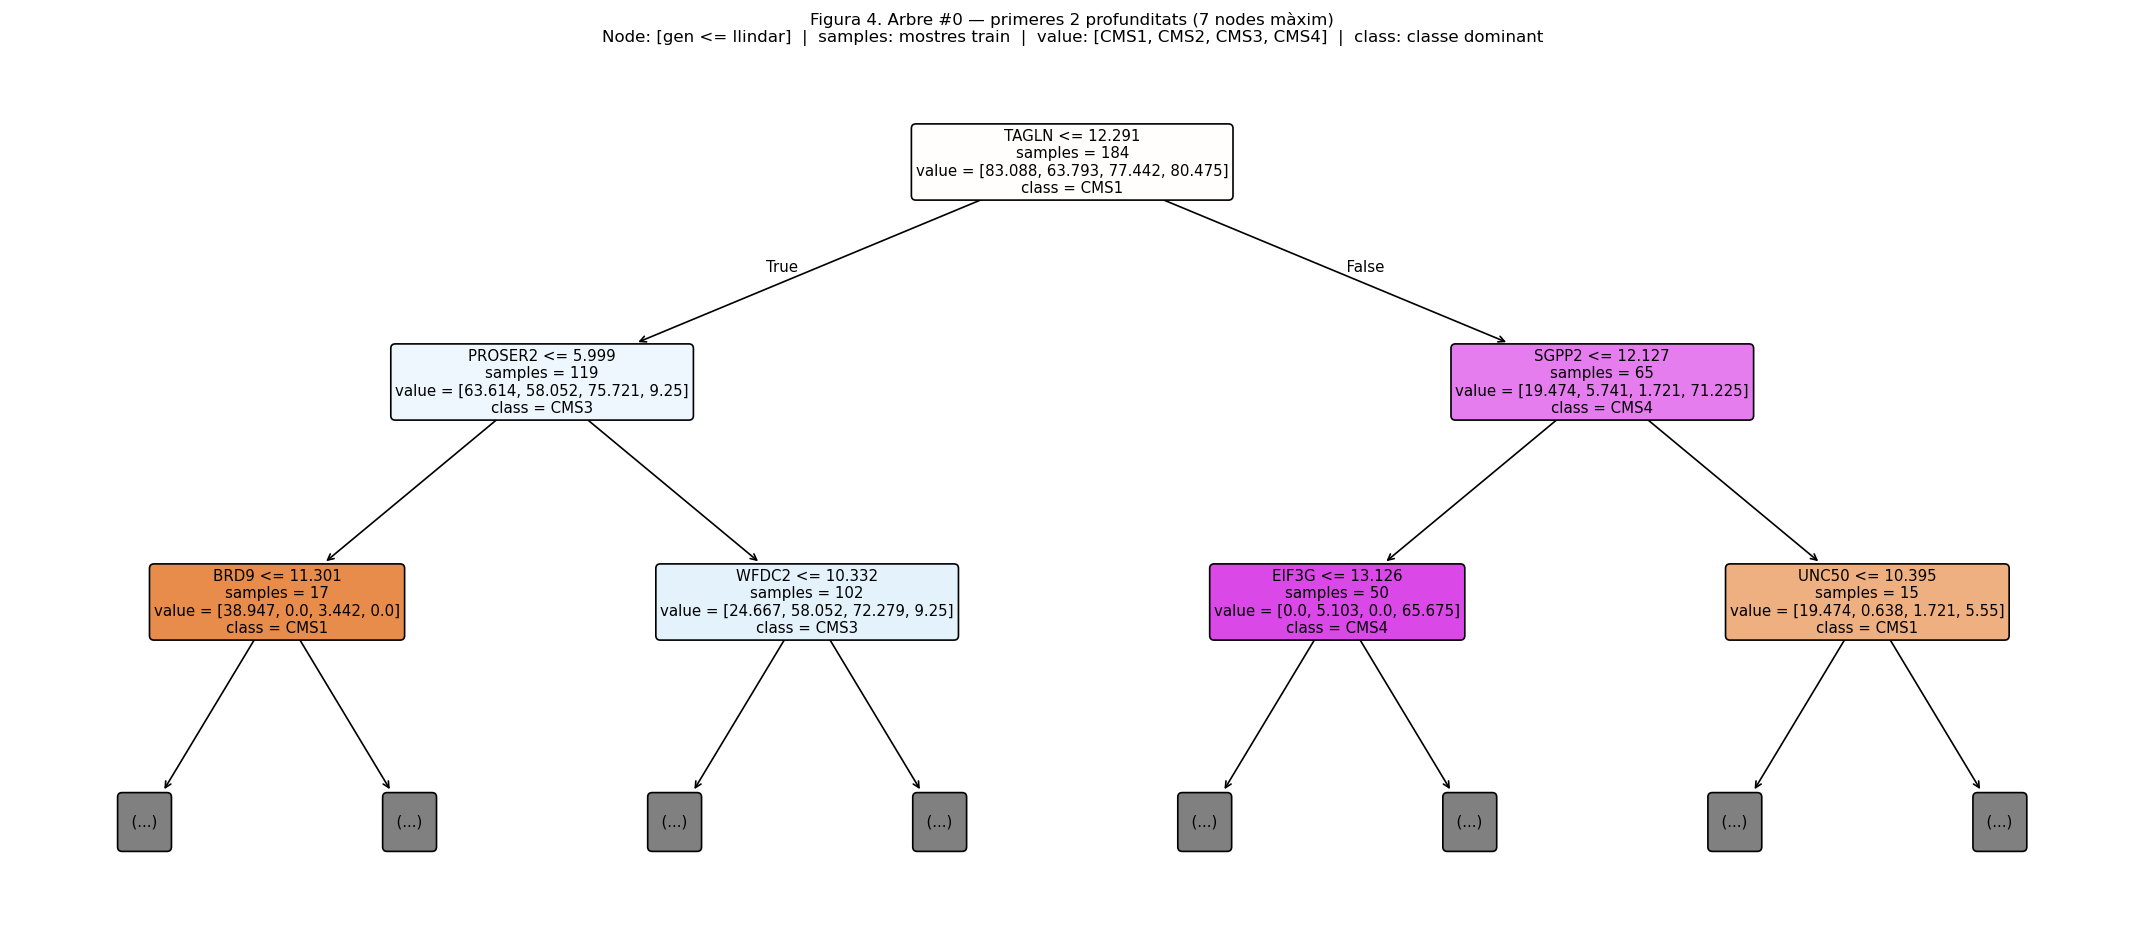

Camí pas a pas de la Mostra 1  (arbre de profunditat màxima 7, 31 fulles):

  Nivell 1: TAGLN
    Expressió de la mostra: 13.51
    Llindar de l'arbre:     12.29
    → Exp > Llindar → fill dret

  Nivell 2: SGPP2
    Expressió de la mostra: 11.23
    Llindar de l'arbre:     12.13
    → Exp <= Llindar → fill esquerre

  Nivell 3: EIF3G
    Expressió de la mostra: 12.81
    Llindar de l'arbre:     13.13
    → Exp <= Llindar → fill esquerre

  Nivell 4: SNRPB
    Expressió de la mostra: 12.58
    Llindar de l'arbre:     14.00
    → Exp <= Llindar → fill esquerre

  Nivell 5: ZNF599
    Expressió de la mostra: 7.94
    Llindar de l'arbre:     8.25
    → Exp <= Llindar → fill esquerre

  Predicció d'aquest arbre: CMS4
  Classe real:              CMS2


In [8]:
from sklearn.tree import plot_tree, _tree

feature_names_readable = [gene_name_map.get(gid, gid) for gid in X_train.columns]
tree_0 = rf_model.estimators_[0]
tree_ = tree_0.tree_

sample = X_test.iloc[0]
sample_real = y_test.values[0]

# --- Pas 1: calcular el camí i recollir els valors de la mostra en cada gen del camí ---
node = 0
path_steps = []
while tree_.feature[node] != _tree.TREE_UNDEFINED:
    gen = feature_names_readable[tree_.feature[node]]
    threshold = tree_.threshold[node]
    val = float(sample.values[tree_.feature[node]])
    go_left = val <= threshold
    path_steps.append({
        'Nivell': f"Nivell {len(path_steps) + 1}",
        'Gen del node': gen,
        'Expressió de la mostra': round(val, 2),
        'Llindar de l\'arbre': round(threshold, 2),
        'Decisió': 'Exp <= Llindar → fill esquerre' if go_left else 'Exp > Llindar → fill dret',
    })
    node = tree_.children_left[node] if go_left else tree_.children_right[node]

predicted_class = CMS_ORDER[int(tree_.value[node].argmax())]

# --- Pas 2: taula prèvia — expressió de la mostra en els gens del camí ---
print(f"Mostra analitzada: Mostra 1 del test set  (classe real: {sample_real})")
print()
print("Valors d'expressió de la mostra en els gens que apareixeran al camí de l'arbre:")
path_df = pd.DataFrame(path_steps).set_index('Nivell')
display(path_df)
print()

# --- Pas 3: diagrama de l'arbre (max_depth=2 per llegibilitat màxima) ---
fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(
    tree_0,
    max_depth=2,
    feature_names=feature_names_readable,
    class_names=CMS_ORDER,
    filled=True,
    ax=ax,
    fontsize=9,
    impurity=False,
    proportion=False,
    rounded=True,
)
plt.title(
    "Figura 4. Arbre #0 — primeres 2 profunditats (7 nodes màxim)\n"
    "Node: [gen <= llindar]  |  samples: mostres train  |  value: [CMS1, CMS2, CMS3, CMS4]  |  class: classe dominant",
    fontsize=10
)
plt.tight_layout()
plt.show()

# --- Pas 4: camí pas a pas ---
print(f"Camí pas a pas de la Mostra 1  (arbre de profunditat màxima {tree_0.get_depth()}, {tree_0.get_n_leaves()} fulles):")
print()
for step in path_steps:
    exp  = step["Expressió de la mostra"]
    llin = step["Llindar de l'arbre"]
    print(f"  {step['Nivell']}: {step['Gen del node']}")
    print(f"    Expressió de la mostra: {exp:.2f}")
    print(f"    Llindar de l'arbre:     {llin:.2f}")
    print(f"    → {step['Decisió']}")
    print()

print(f"  Predicció d'aquest arbre: {predicted_class}")
print(f"  Classe real:              {sample_real}")

**Interpretació de l'estructura de l'arbre i l'exemple pràctic:**

L'exemple mostra el camí real d'una mostra a través de l'arbre #0: en cada node
el model comprova l'expressió d'un gen, compara amb un llindar, i continua cap
a l'esquerra o la dreta. En arribar a una fulla, emet la seva predicció.

**Sí, hi ha 500 arbres com aquest.** Cada un dels 500 s'ha entrenat sobre una
versió lleugerament diferent del dataset (mostres escollides aleatòriament amb
reemplaçament) i ha usat subconjunts aleatoris de ~125 gens en cada decisió.
Per això, cada arbre fa camins lleugerament diferents per a la mateixa mostra.
La predicció final del Random Forest és la classe que apareix més vegades entre
les 500 fulles on aterra la mostra — és a dir, la majoria de vots.

L'ensemble de 500 arbres corregeix el sobreajustament individual de cada arbre,
però en espais d'alta dimensió el guany és limitat comparat amb un classificador
que integra tots els 15.625 gens simultàniament.

### Hipòtesi de rendiment

> **H1b — Random Forest:** Basant-nos en les importàncies molt distribuïdes
> i el nombre limitat de gens per decisió (~125 de 15.625), s'anticipa que
> el Random Forest obtindrà un rendiment inferior als models lineals,
> especialment per a CMS3. La signatura molecular de CMS3 sembla distribuïda
> entre milers de gens — un patró que el mecanisme de divisió nus per nus
> no pot integrar de manera eficient.

---

## 5. SVM (Màquina de Vectors de Suport, kernel lineal)

### Principi de funcionament

L'SVM busca l'hiperplà de separació entre classes que **maximitza el marge**:
la distància entre l'hiperplà i els punts de train més propers.

Per il·lustrar-ho en 2D: donat un conjunt de punts de dues classes, existeixen
infinits separadors lineals vàlids. L'SVM n'escull un de molt específic:
el que passa *al mig* del buit màxim entre ambdues classes.

Els **vectors de suport** son exactament els punts del train que es troben
sobre els marges — els més propers a la frontera de decisió. Teòricament,
si s'eliminessin totes les altres mostres del train, el classificador no canviaria.
En la pràctica, en espais d'alta dimensió, la majoria de mostres tendeixen
a estar prop dels marges, i el nombre de vectors de suport és elevat.

### Formulació matemàtica

**Conceptes previs:** un **hiperplà** en un espai de $D$ dimensions és una superfície
que divideix l'espai en dues meitats. En 2D és una línia; en 3D és un pla; en l'espai
de 15.625 gens, és una superfície que separa els pacients d'una classe dels de la resta.

L'SVM defineix el separador com $\mathbf{w} \cdot \mathbf{x} + b = 0$, on:

- $\mathbf{x}$ és el **vector d'expressió del pacient** — els mateixos 15.625 valors log₂ que el model rep com a entrada
- $\mathbf{w}$ és el **vector de pesos** (un valor per gen; determina l'orientació del separador)
- $b$ és el biaix (desplaçament de l'hiperplà respecte a l'origen)

El **marge** és la distància total entre l'hiperplà i els punts de train més propers de cada
classe. L'SVM cerca l'hiperplà que **maximitza el marge**, perquè un marge gran implica que
el classificador és robust: una mostra lleugerament desplaçada respecte al train continuarà
sent classificada correctament.

Com que el marge val $\frac{2}{\|\mathbf{w}\|}$, maximitzar-lo equivaldrà a **minimitzar**
$\|\mathbf{w}\|^2$ (amb la restricció que totes les mostres estiguin al costat correcte
i fora del marge). Aquesta és la forma matemàtica que resol l'algorisme.

**Per qué kernel lineal?** Amb 15.625 gens (variables) i 296 pacients (mostres), hi ha
tantes dimensions que les dades ja queden separades per un hiperplà simple sense necessitat
de cap transformació addicional.

### Extensió multiclasse (One-vs-Rest) i Platt scaling

**One-vs-Rest (OvR):** sklearn entrena 4 classificadors binaris independents.
Per exemple, el classificador "CMS3 vs. resta" rep totes les 296 mostres de train,
etiquetades com "CMS3" (43 mostres) o "resta" (253 mostres), i aprèn un hiperplà
que les separa amb el marge màxim. Cada classificador té el seu propi hiperplà
i els seus propis vectors de suport:

| Classificador | Positiu | Negatiu |
|:---:|:---:|:---:|
| CMS1 vs. resta | CMS1 (57) | CMS2 + CMS3 + CMS4 (239) |
| CMS2 vs. resta | CMS2 (116) | CMS1 + CMS3 + CMS4 (180) |
| CMS3 vs. resta | CMS3 (43) | CMS1 + CMS2 + CMS4 (253) |
| CMS4 vs. resta | CMS4 (80) | CMS1 + CMS2 + CMS3 (216) |

La classe predita és la que obté la puntuació de decisió (distància a l'hiperplà) més alta.

**Platt scaling** (`probability=True`): per defecte, el SVM retorna únicament la
classe predita, sense cap mesura de confiança. Amb `probability=True`, s'afegeix
un pas que transforma les puntuacions de decisió (que poden ser qualsevol nombre
real) en valors entre 0 i 1 interpretables com a probabilitats. Per fer-ho, s'ajusten
dos paràmetres sobre les dades de train que calibren la transformació. Gràcies a
aquest pas, el SVM retorna probabilitats per classe — de manera anàloga a les
probabilitats softmax de la Regressió Logística — i permet examinar la confiança
del model en cada predicció.

### Vectors de suport al conjunt TCGA-COAD

La cel·la següent compta quantes mostres del train actuen com a vectors
de suport per a cada classificador binari OvR. En espais d'alta dimensió
(15.625 features > 296 mostres), s'espera que la proporció sigui elevada
perquè gairebé totes les mostres es troben prop de les fronteres de decisió.

In [9]:
svm_model = models['svm']

print('Vectors de suport per classificador One-vs-Rest:')
print(f'  Classes: {list(svm_model.classes_)}')
for cls, n in zip(svm_model.classes_, svm_model.n_support_):
    print(f'    {cls}: {n} vectors de suport')

total_sv = svm_model.n_support_.sum()
pct_sv   = total_sv / len(X_train) * 100
print()
print(f'  Total vectors de suport (suma OvR): {total_sv}')
print(f'  % sobre el train set (suma OvR):    {pct_sv:.1f}%')
print()
print("Nota: en espais d'alta dimensió (15.625 gens > 296 mostres), la proporció")
print("de vectors de suport és elevada perquè la majoria de mostres estan prop dels marges.")

Vectors de suport per classificador One-vs-Rest:
  Classes: ['CMS1', 'CMS2', 'CMS3', 'CMS4']
    CMS1: 36 vectors de suport
    CMS2: 66 vectors de suport
    CMS3: 31 vectors de suport
    CMS4: 47 vectors de suport

  Total vectors de suport (suma OvR): 180
  % sobre el train set (suma OvR):    60.8%

Nota: en espais d'alta dimensió (15.625 gens > 296 mostres), la proporció
de vectors de suport és elevada perquè la majoria de mostres estan prop dels marges.


### Puntuacions de decisió

Aclarint la relació entre hiperplà, vectors de suport i classificació:

- L'**hiperplà** és la frontera de decisió (no les mostres de train). En el cas OvR, hi ha 4 hiperplans, un per classificador.
- Els **vectors de suport** son les mostres de train que queden just al límit del marge — les més properes a l'hiperplà. Determinen on es dibuixa la frontera, però no son la frontera en si mateixa.
- La **puntuació de decisió** d'una mostra nova és la seva distància signada a l'hiperplà: **positiva** = la mostra cau al costat de la classe k (el model vota a favor); **negativa** = cau al costat contrari.
- La classe predita és la que obté la **puntuació més alta** — la mostra es troba al costat de l'hiperplà d'aquella classe i queda el més allunyada possible de la frontera.

La cel·la següent mostra les puntuacions de decisió per a les 5 primeres mostres del test.

In [10]:
decision_scores = svm_model.decision_function(X_test.iloc[:5])

dec_df = pd.DataFrame(
    decision_scores,
    columns=svm_model.classes_,
    index=[f'Mostra {i+1}' for i in range(5)]
)
dec_df['Predicció'] = svm_model.predict(X_test.iloc[:5])
dec_df['Real']      = y_test.values[:5]

styled_dec = (
    dec_df.style
    .background_gradient(cmap='RdBu', subset=list(svm_model.classes_))
    .format({c: '{:.3f}' for c in svm_model.classes_})
    .set_caption(
        'Taula 3. Puntuació de decisió del SVM (distància a l\'hiperplà) '
        'per a les 5 primeres mostres de test. '
        'Valors positius: vot a favor; negatius: vot en contra.'
    )
)
display(styled_dec)

,CMS1,CMS2,CMS3,CMS4,Predicció,Real
Mostra 1,-0.272,3.275,0.786,2.199,CMS2,CMS2
Mostra 2,3.226,-0.235,1.081,1.989,CMS1,CMS1
Mostra 3,0.819,2.222,-0.226,3.188,CMS4,CMS4
Mostra 4,3.254,-0.268,0.792,2.240,CMS1,CMS1
Mostra 5,-0.226,3.242,2.179,0.790,CMS2,CMS2


**Interpretació:** la magnitud del valor és proporcional a la distància
geomètrica entre la mostra i l'hiperplà: valors molt positius indiquen
alta confiança en la predicció d'aquella classe.

### Coincidència de gens discriminatius entre LR i SVM

Ambdós models cerquen un separador **lineal** en el mateix espai i obtenen
prediccions idèntiques al test set. Una primera intuïció seria esperar que
els gens amb coeficients més alts fossin els mateixos en tots dos models.
La cel·la següent verifica si aquesta intuïció és correcta: mesura el solapament
entre els top gens i la correlació global entre tots els coeficients.

In [11]:
# coef_df (LR, CMS3) va ser calculat a la cel·la c20-lr-coefs-grid
cms3_idx_svm = list(svm_model.classes_).index('CMS3')
svm_coef_df = pd.DataFrame({
    'gene_id':       X_train.columns,
    'coef_CMS3_SVM': svm_model.coef_[cms3_idx_svm],
})
svm_coef_df['gene_name'] = svm_coef_df['gene_id'].map(gene_name_map).fillna(svm_coef_df['gene_id'])

top10_lr  = set(coef_df.nlargest(10, 'coef_CMS3')['gene_name'])
top10_svm = set(svm_coef_df.nlargest(10, 'coef_CMS3_SVM')['gene_name'])
overlap   = top10_lr & top10_svm

print('Top 10 gens CMS3 — Logistic Regression:')
print(' ', sorted(top10_lr))
print()
print('Top 10 gens CMS3 — SVM:')
print(' ', sorted(top10_svm))
print()
print(f'Gens en comú: {sorted(overlap) if overlap else "(cap)"} ({len(overlap)}/10)')
print()

# Correlació global entre tots els coeficients (mesura si ambdós models "apunten" en la mateixa direcció)
from scipy.stats import pearsonr
corr, pval = pearsonr(coef_df['coef_CMS3'], svm_coef_df['coef_CMS3_SVM'])
print(f'Correlació de Pearson (tots 15.625 coefs LR vs SVM per CMS3): r={corr:.3f} (p={pval:.2e})')
print()

# Concordança de prediccions al test set
lr_preds  = lr_model.predict(X_test)
svm_preds = svm_model.predict(X_test)
n_agree   = (lr_preds == svm_preds).sum()
print(f'Concordança de prediccions LR vs SVM: {n_agree}/{len(X_test)} mostres ({n_agree/len(X_test):.1%})')

Top 10 gens CMS3 — Logistic Regression:
  ['B3GNT6', 'FER1L6', 'ITLN1', 'L1TD1', 'REG3A', 'REG4', 'RETNLB', 'RHBDL3', 'SLITRK6', 'SPINK4']

Top 10 gens CMS3 — SVM:
  ['CALB1', 'CLDN18', 'IGF2BP3', 'IRX2', 'ONECUT3', 'REG4', 'SERPINB2', 'TNNT1', 'TRIM7', 'TRPV6']

Gens en comú: ['REG4'] (1/10)

Correlació de Pearson (tots 15.625 coefs LR vs SVM per CMS3): r=0.124 (p=2.72e-54)

Concordança de prediccions LR vs SVM: 74/74 mostres (100.0%)


**Per qué la coincidència en els top gens és baixa malgrat prediccions idèntiques?**

Malgrat que LR i SVM fan les mateixes prediccions al test set, els seus vectors de
coeficients no coincideixen al top 10. Això és possible perquè en un espai d'alta
dimensió (15.625 dimensions, 296 mostres), **existeixen molts hiperplans lineals que
separen perfectament les classes** — i LR i SVM n'escullen cadascun un de diferent:

- La **LR** minimitza l'error probabilístic: busca el separador que fa que les probabilitats de cada classe siguin el màxim de versemblants
- El **SVM** maximitza el marge geomètric: busca el separador que s'allunya més de les mostres de train

Dos hiperplans que separen exactament les mateixes mostres poden tenir orientacions molt
diferents, i per tant magnituds de coeficients molt diferents per a cada gen.

**Sobre la correlació r=0.124:** pot semblar baixa, però cal interpretar-la correctament.
La p-value és 2.72e-54 — estadísticament significativa amb molta claredat, cosa que vol
dir que la correlació **no és zero**: ambdós models apunten en la *mateixa direcció general*.
Gens que la LR considera pro-CMS3 tendeixen a ser "una mica" pro-CMS3 per l'SVM també,
però les magnituds individuals difereixen molt. Amb 15.625 gens, fins i tot una correlació
petita és detectada amb altíssima certesa estadística.

La **concordança de prediccions** (que el codi calcula a continuació) és la mesura definitiva
de l'equivalència entre models: si tots dos fan les mateixes decisions, son funcionalment
equivalents independentment de com siguin els seus coeficients interns.

**REG4** apareix als top 10 dels dos models perquè la seva associació amb CMS3 és tan
forta que cap criteri d'optimització l'ignora.

### Hipòtesi de rendiment

> **H1c — SVM ≈ LR:** Atès que ambdós models cerquen un separador lineal en el
> mateix espai de 15.625 dimensions i que les dades son linealment separables,
> s'anticipa que les seves prediccions finals seran idèntiques o gairebé idèntiques.
> Malgrat que els coeficients individuals diferiran (hi ha múltiples hiperplans vàlids),
> les decisions finals haurien de coincidir completament.

---

## 6. Prediccions sobre el rendiment en el test set

### Taula comparativa dels tres models

La taula següent resumeix les diferències principals entre els tres classificadors
des del punt de vista de la seva estructura interna i adequació al dataset TCGA-COAD.

In [12]:
synthesis_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'SVM (linear)'],
    'Tipus de separador': [
        'Hiperplà lineal',
        'Regles jeràrquiques binàries',
        'Hiperplà de màxim marge',
    ],
    'Features per decisió': [
        '15.625 (tots)',
        '~125 (√15625)',
        '15.625 (tots)',
    ],
    'Adequació n_feat>>n_samp': ['Alta', 'Limitada', 'Alta'],
    'Temps entrenament (s)': ['~1.75', '~0.84', '~0.73'],
    'Hipòtesi rendiment test': [
        'Elevat',
        'Moderat — dèbil en CMS3',
        'Equivalent a LR',
    ],
}

synthesis_df = pd.DataFrame(synthesis_data).set_index('Model')
display(synthesis_df.style.set_caption(
    'Taula 4. Síntesi comparativa dels tres classificadors.'
))

,Tipus de separador,Features per decisió,Adequació n_feat>>n_samp,Temps entrenament (s),Hipòtesi rendiment test
Model,,,,,
Logistic Regression,Hiperplà lineal,15.625 (tots),Alta,~1.75,Elevat
Random Forest,Regles jeràrquiques binàries,~125 (√15625),Limitada,~0.84,Moderat — dèbil en CMS3
SVM (linear),Hiperplà de màxim marge,15.625 (tots),Alta,~0.73,Equivalent a LR


### Hipòtesis formulades

A partir de l'anàlisi dels paràmetres interns dels tres models, es formulen
les hipòtesis següents sobre el rendiment esperat en el conjunt de test (n=74).

---

**H1 — Logistic Regression i SVM obtindran un rendiment equivalent i elevat.**

Ambdós models cerquen un separador lineal en un espai on les dades ja son
linealment separables. La seva adequació a l'espai d'alta dimensió i la
utilització de tots els 15.625 gens simultàniament els hauria de permetre
capturar la signatura distribuïda dels subtipus CMS. Tot i que els coeficients
individuals diferiran (hi ha múltiples hiperplans vàlids), les prediccions
finals haurien de coincidir.

---

**H2 — El Random Forest obtindrà un rendiment inferior, especialment per a CMS3.**

La restricció a ~125 gens per nus de divisió limita la capacitat del model
per integrar signatures distribuïdes. S'espera que la divergència sigui
particularment notable per a CMS3, on la signatura metabòlica difusa no pot
ser capturada eficientment amb decisions basades en un únic gen.

---

**H3 — Tots tres models superaran de manera substancial un classificador de referència aleatori.**

Un classificador aleatori estratificat obtindria F1 macro ≈ 0.25 (4 classes equiprobables).
Tots tres models haurien d'obtenir un rendiment significativament superior.

---

**La validació d'aquestes hipòtesis amb els resultats reals es presenta al notebook** `results_exploration.ipynb`.